## Análisis Multivariable de los datos

### By:
Maria Camila Sepulveda Torres

### Date:
2024-08-21

### Description:

Análisis exploratorio multivariable del conjunto de datos de admisiones universitarias, con el fin de estudiar la interacción conjunta entre varias variables y la variable objetivo `Chance of Admit`, identificar patrones relevantes y obtener elementos que orienten la preparación de los datos y las etapas posteriores de modelado.


## 📚 Import  libraries

In [2]:
# base libraries for data science
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
# configuración para mostrar únicamente 2 decimales
pd.set_option("display.float_format", "{:.2f}".format)

In [4]:
# versiones de las librerías para garantizar reproducibilidad

print("Versión de Python: ", sys.version)
print("Versión de Pandas: ", pd.__version__)

Versión de Python:  3.12.13 (main, Jul 23 2026, 14:43:28) [Clang 22.1.3 ]
Versión de Pandas:  3.0.5


## 💾 Load data

In [5]:
# ruta del directorio de datos
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

admission_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/admission_type_fixed.parquet",
    engine="pyarrow",
)

In [6]:
# variables categóricas ordinales

admission_df["University Rating"] = pd.Categorical(
    admission_df["University Rating"],
    categories=[1, 2, 3, 4, 5],
    ordered=True,
)

admission_df["SOP"] = pd.Categorical(
    admission_df["SOP"],
    categories=[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    ordered=True,
)

admission_df["LOR"] = pd.Categorical(
    admission_df["LOR"],
    categories=[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    ordered=True,
)

## 📊 Descripción de los datos

In [8]:
admission_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   GRE Score          612 non-null    Int16   
 1   TOEFL Score        604 non-null    Int16   
 2   University Rating  617 non-null    category
 3   SOP                607 non-null    category
 4   LOR                615 non-null    category
 5   CGPA               621 non-null    float64 
 6   Research           594 non-null    boolean 
 7   Chance of Admit    623 non-null    float64 
dtypes: Int16(2), boolean(1), category(3), float64(2)
memory usage: 17.3 KB


## 📊 Analysis of Results and Conclusions 

El análisis multivariable permite estudiar de manera conjunta el comportamiento de varias variables del conjunto de datos y su relación con la variable objetivo `Chance of Admit`.

A diferencia del análisis bivariable, en esta sección se busca identificar patrones que surgen de la interacción simultánea entre múltiples características académicas del aspirante.


### Relación conjunta entre GRE Score, TOEFL Score, CGPA y Chance of Admit

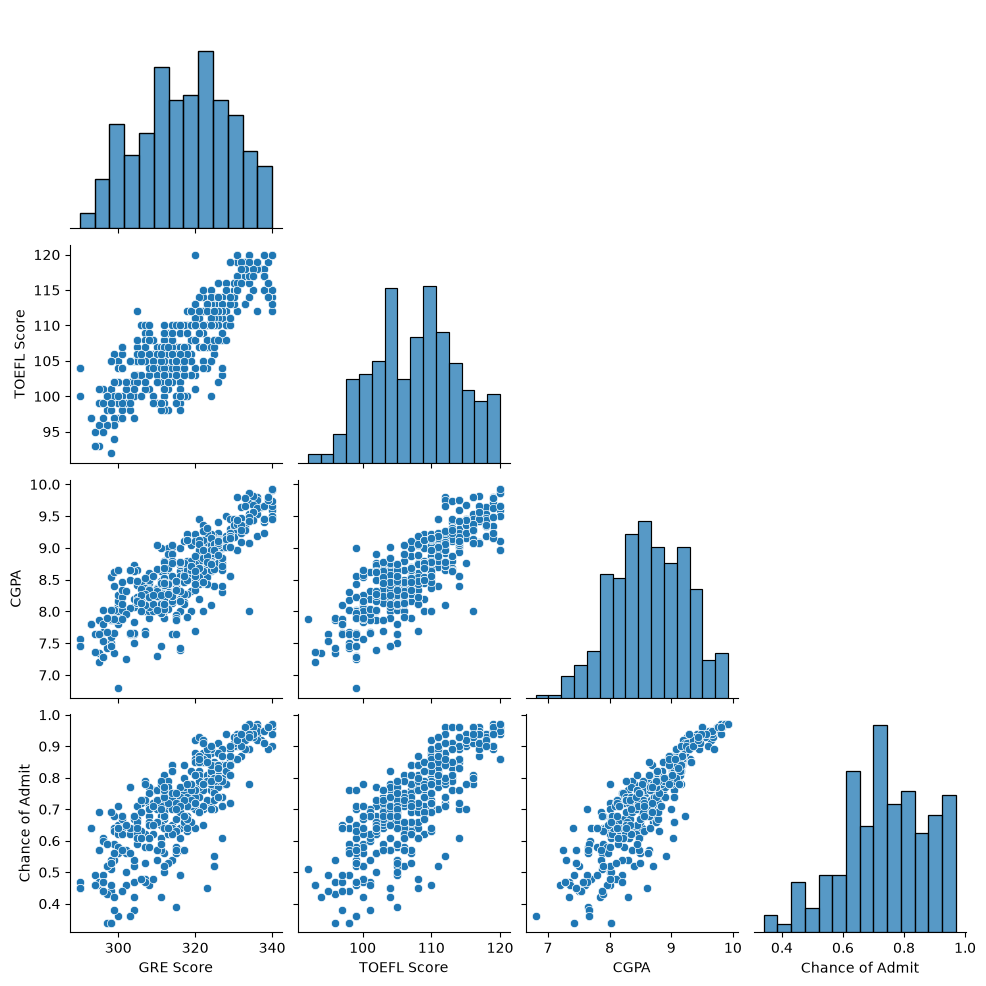

In [ ]:
# relación entre las principales variables académicas

sns.pairplot(
    admission_df[["GRE Score", "TOEFL Score", "CGPA", "Chance of Admit"]].dropna(),
    corner=True,
)

plt.show()

### Interpretación

Se observa una relación positiva entre las principales variables académicas. En general, los aspirantes con mayores puntajes en GRE, TOEFL y CGPA presentan también mayores valores de `Chance of Admit`.

Entre las variables analizadas, CGPA presenta visualmente una relación especialmente marcada con la probabilidad de admisión, consistente con los resultados obtenidos previamente en el análisis bivariable.

También se evidencia una asociación importante entre las propias variables académicas, lo que indica que parte de la información que aportan puede estar relacionada. Este comportamiento deberá considerarse en etapas posteriores del análisis y modelado, especialmente al evaluar la posible presencia de multicolinealidad.

Finalmente, se observan algunos registros alejados del patrón general. Estos valores serán considerados en conjunto con los valores atípicos identificados previamente, sin asumir automáticamente que corresponden a errores.

### Relación entre GRE Score, CGPA y experiencia en investigación

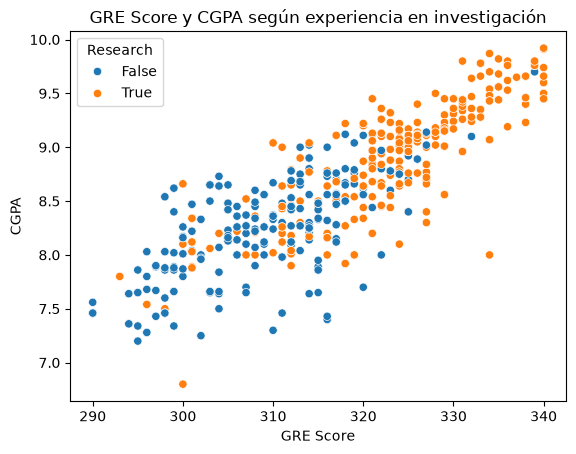

In [11]:
# relación entre GRE Score, CGPA y experiencia en investigación

research_plot_df = admission_df[["GRE Score", "CGPA", "Research"]].dropna()

sns.scatterplot(
    data=research_plot_df,
    x="GRE Score",
    y="CGPA",
    hue="Research",
)

plt.title("GRE Score y CGPA según experiencia en investigación")
plt.xlabel("GRE Score")
plt.ylabel("CGPA")
plt.show()

### Interpretación

Se observa una relación positiva entre `GRE Score` y `CGPA`, de manera que los aspirantes con mayores puntajes GRE tienden a presentar también mayores valores de CGPA.

Al incorporar la variable `Research`, se evidencia que los aspirantes con experiencia en investigación se concentran con mayor frecuencia en los niveles altos de ambas variables académicas, mientras que aquellos sin experiencia en investigación presentan una mayor concentración en niveles bajos e intermedios.

Sin embargo, existe una superposición considerable entre ambos grupos, por lo que la experiencia en investigación no permite diferenciarlos completamente por sí sola. Esto sugiere que `Research` puede aportar información complementaria cuando se analiza conjuntamente con otras características académicas.

### Relación entre GRE Score, CGPA y probabilidad de admisión

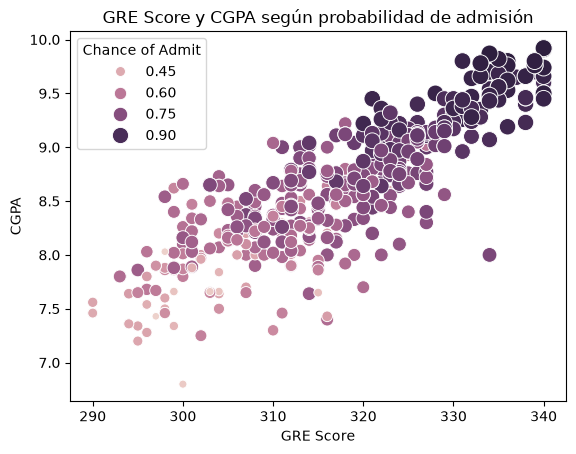

In [12]:
# relación entre GRE Score, CGPA y probabilidad de admisión

admission_plot_df = admission_df[["GRE Score", "CGPA", "Chance of Admit"]].dropna()

sns.scatterplot(
    data=admission_plot_df,
    x="GRE Score",
    y="CGPA",
    hue="Chance of Admit",
    size="Chance of Admit",
    sizes=(30, 150),
)

plt.title("GRE Score y CGPA según probabilidad de admisión")
plt.xlabel("GRE Score")
plt.ylabel("CGPA")
plt.show()

### Interpretación

Se observa que la probabilidad de admisión tiende a aumentar a medida que se incrementan conjuntamente `GRE Score` y `CGPA`. Los aspirantes ubicados en los niveles superiores de ambas variables presentan, en general, mayores valores de `Chance of Admit`.

El patrón evidencia que la combinación de características académicas permite observar con mayor claridad el comportamiento de la variable objetivo que el análisis aislado de una sola característica.

Sin embargo, también se identifican algunos registros que se apartan de la tendencia general, lo que indica que valores altos en una característica académica no necesariamente implican por sí solos una alta probabilidad de admisión. Esto respalda la necesidad de considerar múltiples variables de manera conjunta en las etapas posteriores de modelado.

### Análisis de multicolinealidad entre variables predictoras

In [13]:
# correlación entre variables predictoras numéricas

predictor_columns = [
    "GRE Score",
    "TOEFL Score",
    "CGPA",
]

predictor_correlation = admission_df[predictor_columns].corr()

predictor_correlation.round(2)

,GRE Score,TOEFL Score,CGPA
GRE Score,1.00,0.85,0.84
TOEFL Score,0.85,1.00,0.84
CGPA,0.84,0.84,1.00


### Interpretación

Las variables predictoras analizadas presentan correlaciones positivas altas entre sí. La mayor asociación se observa entre `GRE Score` y `TOEFL Score` (0.85), mientras que `GRE Score` y `CGPA`, así como `TOEFL Score` y `CGPA`, presentan correlaciones de 0.84.

Estos resultados indican que las principales características académicas comparten una cantidad importante de información. Por lo tanto, existe un indicio de posible multicolinealidad entre los predictores, aspecto que debe ser considerado en las etapas posteriores de modelado.

Sin embargo, la correlación entre pares de variables no es suficiente por sí sola para determinar la existencia de un problema de multicolinealidad. Por esta razón, se requiere complementar este análisis mediante una medida específica que permita evaluar el efecto conjunto de los predictores.

### Relación entre University Rating, CGPA y probabilidad de admisión

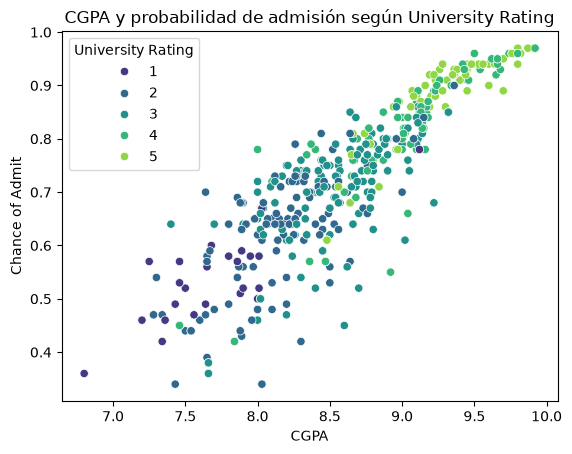

In [16]:
# relación entre University Rating, CGPA y probabilidad de admisión

university_plot_df = admission_df[["University Rating", "CGPA", "Chance of Admit"]].dropna()

sns.scatterplot(
    data=university_plot_df,
    x="CGPA",
    y="Chance of Admit",
    hue="University Rating",
    palette="viridis",
)

plt.title("CGPA y probabilidad de admisión según University Rating")
plt.xlabel("CGPA")
plt.ylabel("Chance of Admit")
plt.show()

### Interpretación

Se observa una relación positiva entre `CGPA` y `Chance of Admit`, donde los aspirantes con mayor promedio académico tienden a presentar mayores probabilidades de admisión.

Al incorporar `University Rating`, se evidencia que las categorías más altas, especialmente 4 y 5, se concentran con mayor frecuencia en los niveles superiores de CGPA y probabilidad de admisión. Por su parte, las categorías más bajas presentan una mayor concentración en valores bajos e intermedios.

Sin embargo, existe superposición entre las diferentes categorías de `University Rating`, lo que indica que esta variable no determina por sí sola la probabilidad de admisión. Los resultados sugieren que su aporte debe interpretarse conjuntamente con otras características académicas, como el CGPA.

### Relación entre CGPA, experiencia en investigación y probabilidad de admisión

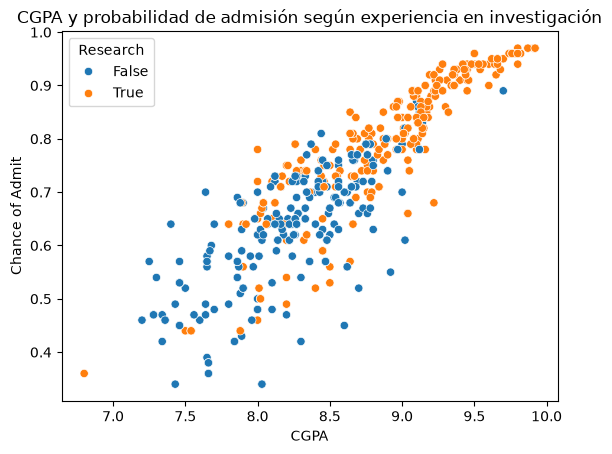

In [17]:
# relación entre CGPA, experiencia en investigación y probabilidad de admisión

research_admit_df = admission_df[["CGPA", "Research", "Chance of Admit"]].dropna()

sns.scatterplot(
    data=research_admit_df,
    x="CGPA",
    y="Chance of Admit",
    hue="Research",
)

plt.title("CGPA y probabilidad de admisión según experiencia en investigación")
plt.xlabel("CGPA")
plt.ylabel("Chance of Admit")
plt.show()

### Interpretación

Se observa una relación positiva entre `CGPA` y `Chance of Admit`, donde los aspirantes con mayores valores de CGPA tienden a presentar mayores probabilidades de admisión.

Al incorporar la variable `Research`, los aspirantes con experiencia en investigación se concentran con mayor frecuencia en los niveles altos de CGPA y probabilidad de admisión. Sin embargo, en los niveles intermedios existe una superposición considerable entre los aspirantes con y sin experiencia en investigación.

Por lo tanto, `Research` parece aportar información complementaria al comportamiento observado entre CGPA y probabilidad de admisión, pero no permite diferenciar completamente a los aspirantes por sí sola. Estos resultados representan asociaciones dentro del conjunto de datos y no implican una relación causal.

## 📊 Analysis of Results and Conclusions 

## 📝 Conclusiones del análisis multivariable

El análisis multivariable permitió identificar patrones conjuntos entre las características académicas de los aspirantes y la variable objetivo `Chance of Admit`.

Las variables `GRE Score`, `TOEFL Score` y `CGPA` presentan relaciones positivas entre sí y, en conjunto, muestran una asociación clara con la probabilidad de admisión. Los aspirantes con valores académicos más altos tienden a concentrarse en los niveles superiores de `Chance of Admit`.

Entre las variables analizadas, `CGPA` muestra una relación especialmente marcada con la probabilidad de admisión. Sin embargo, los resultados evidencian que ninguna característica debe interpretarse de manera aislada, ya que la combinación de diferentes variables permite representar mejor el comportamiento de la variable objetivo.

La incorporación de `University Rating` muestra que las categorías superiores se concentran con mayor frecuencia en aspirantes con altos valores de CGPA y probabilidad de admisión. No obstante, existe superposición entre las diferentes categorías, por lo que esta característica aporta información complementaria pero no determina por sí sola el comportamiento de `Chance of Admit`.

De manera similar, los aspirantes con experiencia en investigación (`Research = True`) se concentran con mayor frecuencia en niveles altos de desempeño académico y probabilidad de admisión. Sin embargo, existe superposición con los aspirantes sin experiencia en investigación, especialmente en los niveles intermedios, por lo que esta variable también debe analizarse conjuntamente con las demás características.

Adicionalmente, las correlaciones altas observadas entre `GRE Score`, `TOEFL Score` y `CGPA` indican que estas variables comparten una cantidad importante de información. Este resultado constituye un indicio de posible multicolinealidad y deberá ser considerado al seleccionar y evaluar los modelos posteriores.


En conjunto, los resultados muestran que la probabilidad de admisión está asociada con múltiples características académicas y que su análisis conjunto proporciona una representación más completa de los patrones presentes en los datos. Estos hallazgos servirán como base para las etapas posteriores de preparación, selección de características y modelado.
